# 04 — XGBoost Baseline (v2: full feature set)

Trains the supervised fraud-scoring model on the full encoded feature set (~75 features from `model_features.csv`).

**Evaluation design:** time-based 70/10/20 split — always tested on *future* transactions. **v2 change:** feature list is read from `feature_list.json` (single source of truth, shared with notebook 06).

**Outputs:** `models/xgb_fraud_model.pkl`, `models/model_metrics.json`, PR-curve and importance charts in `reports/`.

In [1]:
# CELL 1 - Load modeling dataset, sort chronologically
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/model_features.csv")   # v2: encoded features
df["TransactionDT"] = pd.to_datetime(df["TransactionDT"])
df = df.sort_values("TransactionDT").reset_index(drop=True)

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
print(f"Loaded: {df.shape}")

Loaded: (590540, 84)


In [2]:
# CELL 2 - velocity_risk fallback (created in 03; this keeps 04 standalone)
if "velocity_risk" not in df.columns:
    df["velocity_risk"] = (
        df["txn_count_1h"] / df["txn_count_24h"].clip(lower=1)
    ).clip(0, 1)

In [3]:
# CELL 3 - Feature set: single source of truth from the encoding step
features = json.load(open("../data/processed/feature_list.json"))
print(f"{len(features)} features loaded from feature_list.json")

X = df[features]
y = df["isFraud"]

74 features loaded from feature_list.json


In [4]:
# CELL 4 - TIME-BASED split: train on the past, test on the FUTURE
n = len(df)
train_end, val_end = int(n * 0.70), int(n * 0.80)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val     = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test   = X.iloc[val_end:], y.iloc[val_end:]

for name, s in [("train", slice(0, train_end)),
                ("val", slice(train_end, val_end)),
                ("test", slice(val_end, n))]:
    part = df.iloc[s]
    print(f"{name:>5}: {len(part):>7,} rows | "
          f"{part['TransactionDT'].min():%Y-%m-%d} -> "
          f"{part['TransactionDT'].max():%Y-%m-%d} | "
          f"fraud rate {part['isFraud'].mean():.2%}")

train: 413,378 rows | 1970-01-02 -> 1970-05-01 | fraud rate 3.52%
  val:  59,054 rows | 1970-05-01 -> 1970-05-22 | fraud rate 3.49%
 test: 118,108 rows | 1970-05-22 -> 1970-07-02 | fraud rate 3.44%


In [5]:
# CELL 5 - Class imbalance weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")
# NOTE: scores are used for RANKING; thresholds are chosen from the
# tradeoff table below, not read as calibrated probabilities.

scale_pos_weight: 27.4


In [6]:
# CELL 6 - Train with early stopping on the validation window
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"best iteration: {model.best_iteration}")

best iteration: 1844


In [7]:
# CELL 7 - Evaluate on the held-out FUTURE test window
from sklearn.metrics import roc_auc_score, average_precision_score

yt = y_test.to_numpy()
y_scores = model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(yt, y_scores)
ap = average_precision_score(yt, y_scores)
base = yt.mean()

print(f"ROC-AUC:            {roc:.4f}")
print(f"PR-AUC (avg prec.): {ap:.4f}   (baseline rate = {base:.4f})")
print(f"lift over baseline: {ap / base:.1f}x")

ROC-AUC:            0.8924
PR-AUC (avg prec.): 0.4732   (baseline rate = 0.0344)
lift over baseline: 13.8x


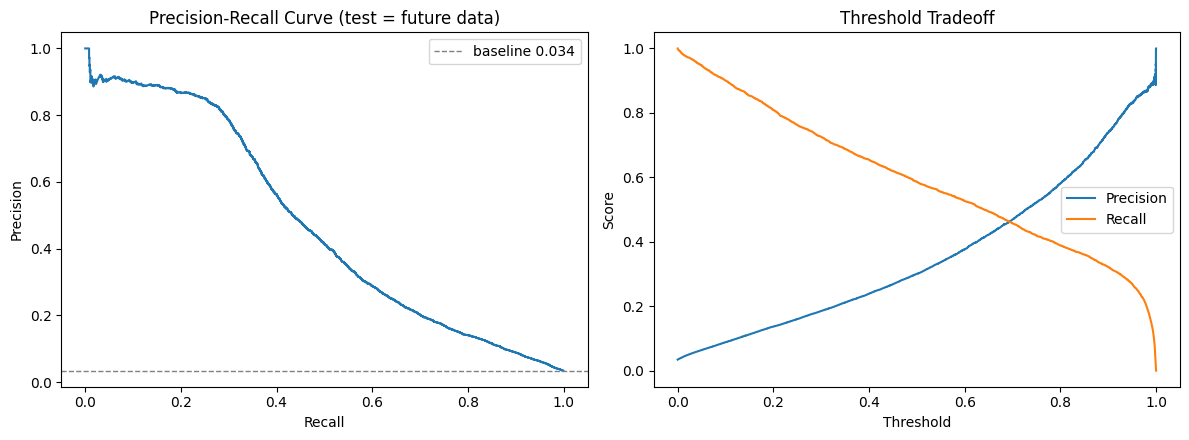

In [8]:
# CELL 8 - PR curve + threshold tradeoff
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(yt, y_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(recall, precision)
axes[0].axhline(base, ls="--", c="gray", lw=1, label=f"baseline {base:.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (test = future data)")
axes[0].legend()
axes[1].plot(thresholds, precision[:-1], label="Precision")
axes[1].plot(thresholds, recall[:-1], label="Recall")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Threshold Tradeoff"); axes[1].legend()
plt.tight_layout()
plt.savefig("../reports/xgb_baseline_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# CELL 9 - Threshold table: what each cutoff costs operationally
rows = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    alert = y_scores >= t
    rows.append({
        "threshold": t,
        "alert_rate_%": round(alert.mean() * 100, 2),
        "precision": round(yt[alert].mean(), 3) if alert.any() else np.nan,
        "recall": round((yt & alert).sum() / yt.sum(), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

 threshold  alert_rate_%  precision  recall
      0.10         35.11      0.088   0.900
      0.20         20.33      0.137   0.809
      0.30         13.48      0.185   0.726
      0.40          9.42      0.239   0.655
      0.50          6.71      0.300   0.586
      0.60          4.81      0.377   0.526
      0.70          3.35      0.469   0.457
      0.75          2.76      0.523   0.420
      0.80          2.30      0.581   0.388
      0.90          1.49      0.740   0.321


In [10]:
# CELL 10 - Two-tier fraud policy (tuned from the cell-9 table)
BLOCK_THRESHOLD = 0.90        # high confidence -> auto-block
INVESTIGATE_THRESHOLD = 0.70  # mid-range -> AI-assisted investigation

block = y_scores >= BLOCK_THRESHOLD
review = (y_scores >= INVESTIGATE_THRESHOLD) & ~block
approve = ~block & ~review

print(f"auto-block:   {block.mean():7.2%} of txns | "
      f"precision {yt[block].mean():.3f} | {yt[block].sum():,} frauds caught")
print(f"investigate:  {review.mean():7.2%} of txns | "
      f"precision {yt[review].mean():.3f} | {yt[review].sum():,} frauds caught")
print(f"auto-approve: {approve.mean():7.2%} of txns")
print(f"fraud captured by block+investigate: "
      f"{yt[block | review].sum() / yt.sum():.1%}")

auto-block:     1.49% of txns | precision 0.740 | 1,306 frauds caught
investigate:    1.86% of txns | precision 0.251 | 552 frauds caught
auto-approve:  96.65% of txns
fraud captured by block+investigate: 45.7%


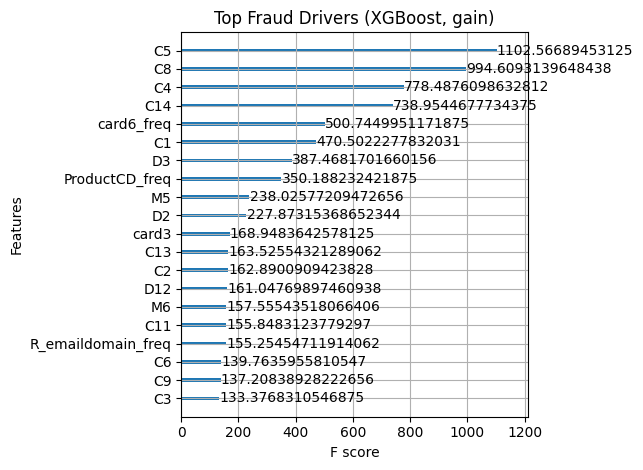

In [11]:
# CELL 11 - Feature importance (top 20 of full set)
xgb.plot_importance(model, max_num_features=20, importance_type="gain")
plt.title("Top Fraud Drivers (XGBoost, gain)")
plt.tight_layout()
plt.savefig("../reports/xgb_baseline_feature_importance.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [12]:
# CELL 12 - Save model + metrics
import joblib

joblib.dump(model, "../models/xgb_fraud_model.pkl")

metrics = {
    "roc_auc": round(float(roc), 4),
    "pr_auc": round(float(ap), 4),
    "base_rate_test": round(float(base), 4),
    "split": "time-based 70/10/20 (train/val/test)",
    "n_features": len(features),
    "block_threshold": BLOCK_THRESHOLD,
    "investigate_threshold": INVESTIGATE_THRESHOLD,
}
with open("../models/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

{
  "roc_auc": 0.8924,
  "pr_auc": 0.4732,
  "base_rate_test": 0.0344,
  "split": "time-based 70/10/20 (train/val/test)",
  "n_features": 74,
  "block_threshold": 0.9,
  "investigate_threshold": 0.7
}
